In [1]:
# Skip this if dataset already downloaded

!wget https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz -O urban8k.tgz
!tar -xzf urban8k.tgz
!rm urban8k.tgz

--2023-12-05 16:52:16--  https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz
Resolving zenodo.org (zenodo.org)... 188.184.103.159, 188.184.98.238, 188.185.79.172, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.159|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1203745/files/UrbanSound8K.tar.gz [following]
--2023-12-05 16:52:16--  https://zenodo.org/records/1203745/files/UrbanSound8K.tar.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 6023741708 (5.6G) [application/octet-stream]
Saving to: ‘urban8k.tgz’

urban8k.tgz         100%[===================>]   5.61G  31.4MB/s    in 61s     

2023-12-05 16:53:17 (93.5 MB/s) - ‘urban8k.tgz’ saved [6023741708/6023741708]



In [2]:
!nvidia-smi

Tue Dec  5 16:55:16 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   33C    P0    24W / 300W |      0MiB / 16384MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical

import librosa
import IPython.display as ipd
from pathlib import Path
from tqdm.auto import tqdm

In [4]:
# PATH - Location of dataset, SAVE_MODELS_PATH - Location to save best models

PATH = Path("UrbanSound8K")
PATH

PosixPath('UrbanSound8K')

In [5]:
# Hyperparameters

DATA_AUGMENTATION = False  # Very slow
N_MFCC = 128
n_fft = 1024
target_sr = 22050

# Data preparation

In [6]:
# Putting the metadata into a pandas dataframe

metadata_path = PATH / "metadata" / "UrbanSound8K.csv"
df = pd.read_csv(metadata_path)
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [7]:
# Dataset balance

df.value_counts('class')

class
air_conditioner     1000
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
jackhammer          1000
street_music        1000
siren                929
car_horn             429
gun_shot             374
dtype: int64

## Visualizing a random sample

In [8]:
# Extract a random fold into a list

rand_wav_dir = PATH / "audio" / f"fold{str(np.random.randint(1, 11))}"
files = librosa.util.find_files(rand_wav_dir)
files[:3]

['/content/UrbanSound8K/audio/fold9/101729-0-0-1.wav',
 '/content/UrbanSound8K/audio/fold9/101729-0-0-11.wav',
 '/content/UrbanSound8K/audio/fold9/101729-0-0-12.wav']

In [9]:
# Extract a random sample from the random fold

rand = np.random.randint(0, len(files))
audio_sample, sample_rate = librosa.load(files[rand])

file_name = files[rand].split("/")[-1]
df_file_entry = df[df['slice_file_name'] == file_name]
label = df_file_entry['class'].values[0]

audio_sample, label, len(audio_sample)

(array([-0.01207817, -0.00593209,  0.01097375, ...,  0.00527302,
        -0.03785712, -0.1016762 ], dtype=float32),
 'drilling',
 88200)

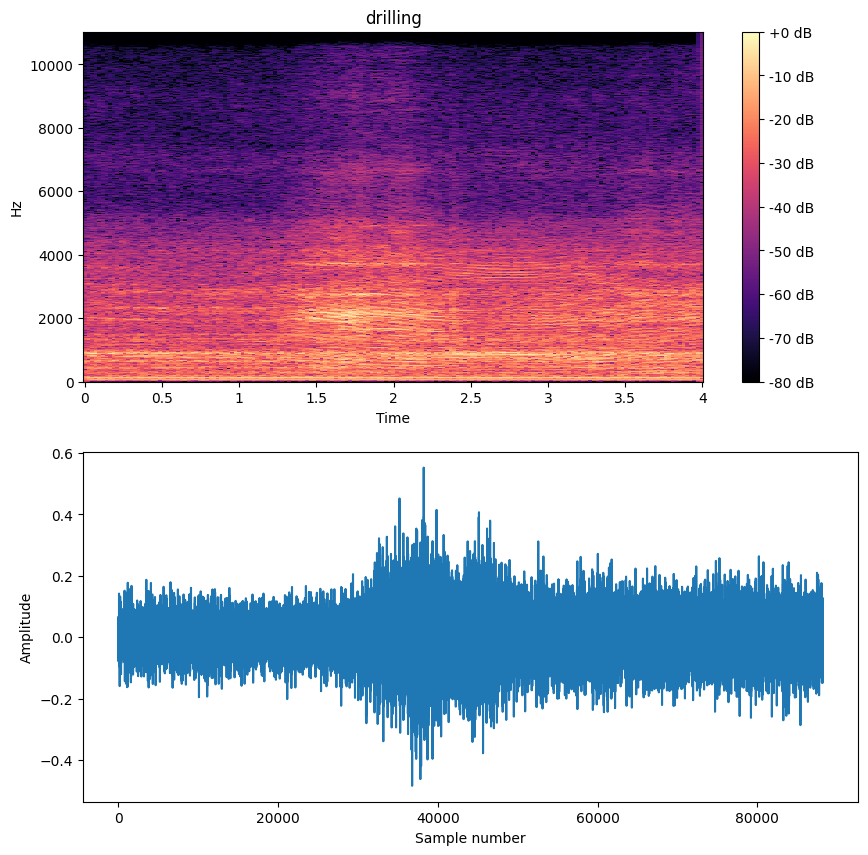

In [10]:
# Spectogram of previous sample

fig = plt.figure(figsize=(10, 10))
rows, cols = 2, 1
plt.subplot(2, 1, 1)

D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_sample)), ref=np.max)
librosa.display.specshow(D, y_axis='linear', x_axis='time')
plt.title(label)
plt.colorbar(format='%+2.0f dB')

plt.subplot(2, 1, 2)
plt.plot(audio_sample)
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
ipd.Audio(files[rand])

## Preprocessing techniques

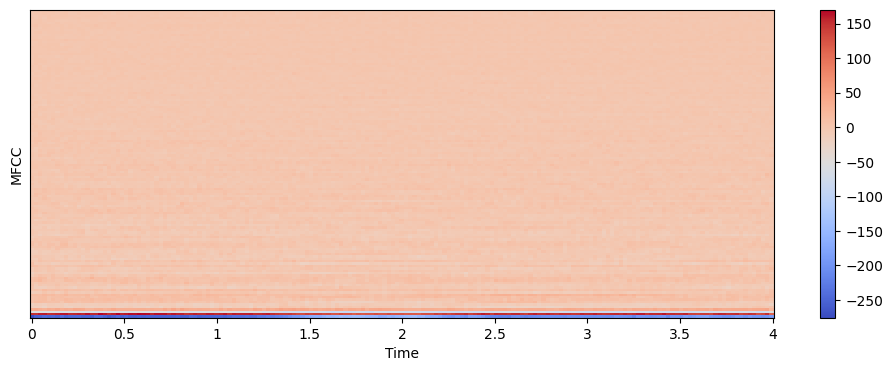

In [11]:
# MFCCs of a random sample

plt.figure(figsize=(12, 4))
res = librosa.resample(audio_sample, orig_sr=sample_rate, target_sr=22050)
if len(res) < 88200:
    res = np.concatenate((res, np.zeros(88200-len(res))), axis=0)
elif len(res) > 88200:
    res = res[:88200]
mfccs = librosa.feature.mfcc(y=res, sr=22050, n_mfcc=128, n_fft=1024)
librosa.display.specshow(mfccs, sr=sample_rate, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar();

(128, 173)


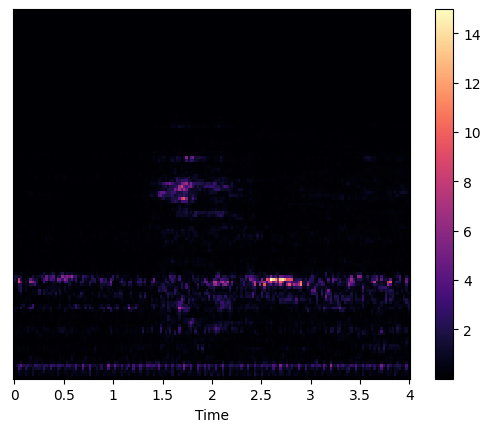

In [12]:
# Mel-spectrogram of a random sample

res = librosa.resample(audio_sample, orig_sr=sample_rate, target_sr=22050)
if len(res) < 88200:
    res = np.concatenate((res, np.zeros(88200-len(res))), axis=0)
elif len(res) > 88200:
    res = res[:88200]
spectrogram = librosa.feature.melspectrogram(y=res, sr=22050, n_fft=1024)
print(spectrogram.shape)
librosa.display.specshow(spectrogram, sr=sample_rate, x_axis='time')
plt.colorbar();

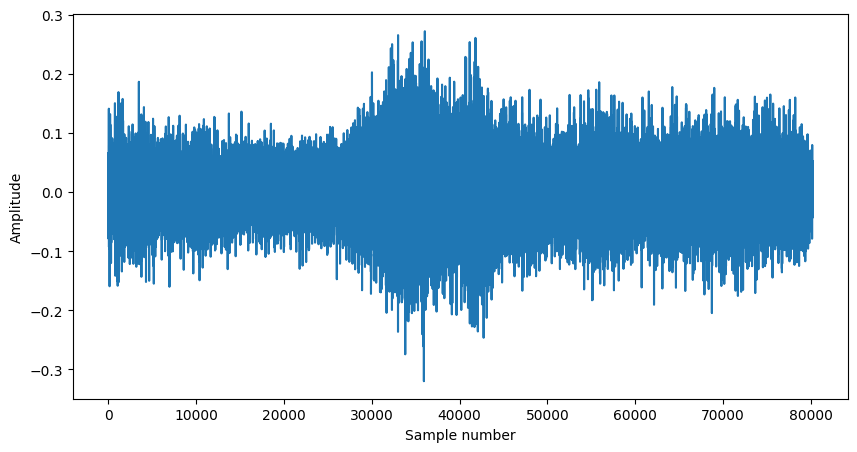

In [13]:
# Data augmentation techniques: Speed shift

audio_replica = audio_sample.copy()
speed_shift = librosa.effects.time_stretch(audio_replica, rate=1.1)

plt.figure(figsize=(10, 5))
plt.plot(speed_shift)
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
ipd.Audio(speed_shift, rate=sample_rate)

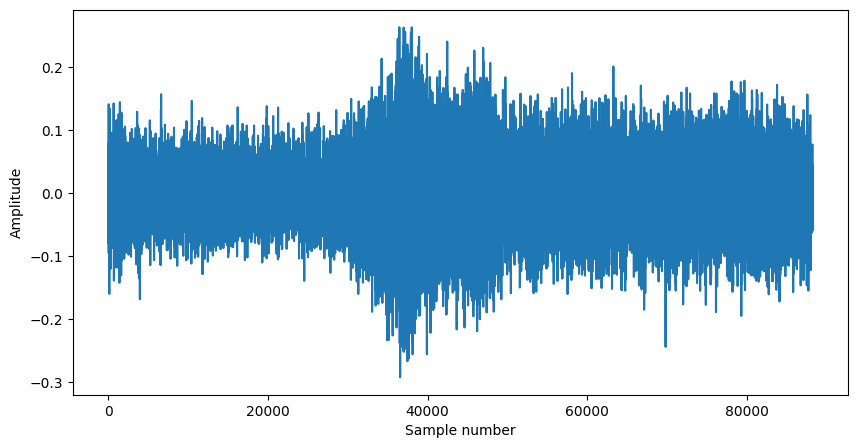

In [14]:
# Data augmentation techniques: Pitch shift
bins_per_octave = 12  # 12 = semitone


audio_replica = audio_sample.copy()
pitch_shift = librosa.effects.pitch_shift(audio_replica,
                                          sr=sample_rate,
                                          bins_per_octave=bins_per_octave,
                                          n_steps=2)

plt.figure(figsize=(10, 5))
plt.plot(pitch_shift)
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
ipd.Audio(pitch_shift, rate=sample_rate)

## Data preprocessing

In [16]:
def get_augmentations(file_path):
    ''' Create more samples with data augmentation. '''

    X, sr = librosa.load(file_path, sr=None, res_type='kaiser_fast')

    speed_shift1 = librosa.effects.time_stretch(X.copy(), rate=1.23)
    speed_shift2 = librosa.effects.time_stretch(X.copy(), rate=1.07)
    speed_shift3 = librosa.effects.time_stretch(X.copy(), rate=0.93)
    speed_shift4 = librosa.effects.time_stretch(X.copy(), rate=0.81)
    pitch_shift1 = librosa.effects.pitch_shift(X.copy(),
                                               sr=sr,
                                               bins_per_octave=bins_per_octave,
                                               n_steps=-1)
    pitch_shift2 = librosa.effects.pitch_shift(X.copy(),
                                               sr=sr,
                                               bins_per_octave=bins_per_octave,
                                               n_steps=1)
    pitch_shift3 = librosa.effects.pitch_shift(X.copy(),
                                               sr=sr,
                                               bins_per_octave=bins_per_octave,
                                               n_steps=-2)
    pitch_shift4 = librosa.effects.pitch_shift(X.copy(),
                                               sr=sr,
                                               bins_per_octave=bins_per_octave,
                                               n_steps=2)

    return [speed_shift1, speed_shift2, speed_shift3, speed_shift4,
            pitch_shift1, pitch_shift2, pitch_shift3, pitch_shift4], sr


In [17]:
N_MFCC = 128
n_fft = 1024
target_sr = 22050

def get_features(file_path):
    ''' Extracts numerical features from an audio file. '''

    X, sr = librosa.load(file_path, sr=None, res_type='kaiser_fast')
    X_res = librosa.resample(X, orig_sr=sr, target_sr=target_sr)
    if len(X_res) < 88200:
        X_res = np.concatenate((X_res, np.zeros(88200-len(X_res))), axis=0)
    elif len(X_res) > 88200:
        X_res = X_res[:88200]
    X_mfcc = librosa.feature.mfcc(y=X_res, sr=target_sr, n_mfcc=N_MFCC, n_fft=n_fft)
    scaler = StandardScaler()
    X_mfcc_scaled_CNN = scaler.fit_transform(X_mfcc)
    X_mfcc_scaled_MLP = np.mean(X_mfcc_scaled_CNN.T, axis=0)

    return X_mfcc_scaled_MLP, X_mfcc_scaled_CNN

In [18]:
# Build the dataset

wav_dir = PATH / "audio"
mlp_features = []
cnn_features = []

for _, row in tqdm(df.iterrows()):
    file_path = wav_dir / f"fold{row['fold']}" / row['slice_file_name']
    MLP_audio, CNN_audio = get_features(file_path)
    label = row['classID']
    fold = row['fold']
    mlp_features.append([MLP_audio, fold, label])
    cnn_features.append([CNN_audio, fold, label])

# For simplicity and flexibility, the data will be stored in a new dataframe
mlp_features_df = pd.DataFrame(mlp_features, columns=['features', 'fold', 'class'])
cnn_features_df = pd.DataFrame(cnn_features, columns=['features', 'fold', 'class'])

0it [00:00, ?it/s]

In [19]:
# New dataframe (dataset)

cnn_features_df.head()

,features,fold,class
0,"[[-10.911253853391441, -9.355875995903988, -7....",5,3
1,"[[-11.08174, -10.9875765, -11.015315, -11.0053...",5,2
2,"[[-11.021904, -10.882805, -10.946565, -10.9578...",5,2
3,"[[-10.891667, -10.916152, -10.863766, -10.8917...",5,2
4,"[[-10.908218, -10.89408, -10.911376, -10.89634...",5,2


In [20]:
# Generate artificial data (data augmentation)

if DATA_AUGMENTATION:
  mlp_augmentations = []
  cnn_augmentations = []

  for _, row in tqdm(df.iterrows()):
      file_path = wav_dir / f"fold{row['fold']}" / row['slice_file_name']
      label = row['classID']
      fold = row['fold']

      X_augs, sr = get_augmentations(file_path)
      for X_aug in X_augs:
          X_res = librosa.resample(X_aug, orig_sr=sr, target_sr=target_sr)
          if len(X_res) < 88200:
              X_res = np.concatenate((X_res, np.zeros(88200-len(X_res))), axis=0)
          elif len(X_res) > 88200:
              X_res = X_res[:88200]
          X_mfcc = librosa.feature.mfcc(y=X_res, sr=target_sr, n_mfcc=N_MFCC, n_fft=n_fft)
          scaler = StandardScaler()
          X_mfcc_scaled_CNN = scaler.fit_transform(X_mfcc)
          X_mfcc_scaled_MLP = np.mean(X_mfcc_scaled_CNN.T, axis=0)
          mlp_augmentations.append([X_mfcc_scaled_MLP, fold, label])
          cnn_augmentations.append([X_mfcc_scaled_CNN, fold, label])

  mlp_augmentations_df = pd.DataFrame(mlp_augmentations, columns=['features', 'fold', 'class'])
  cnn_augmentations_df = pd.DataFrame(cnn_augmentations, columns=['features', 'fold', 'class'])

In [21]:
# Categorical labels

labels = np.array(mlp_features_df['class'].tolist())
labels = to_categorical(labels)
labels.shape

(8732, 10)

In [22]:
# Save data to avoid feature extraction if kernel crashes

%store mlp_features_df
%store cnn_features_df

Stored 'mlp_features_df' (DataFrame)
Stored 'cnn_features_df' (DataFrame)


# Models

**Note:** In case the kernel crashes, run the %store -r command to get the stored variables and avoid data preprocessing again. It might also be necessary to run the hyperparameter cell defined at the start of the notebook for model initialization.

In [23]:
%store -r

In [24]:
mlp_features_df

,features,fold,class
0,"[-11.088334906287171, 0.2662859047863777, -0.2...",5,3
1,"[-10.8577, 2.2530558, -0.90445, 1.1963987, 0.2...",5,2
2,"[-10.889956, 2.3776166, -0.7314677, 0.9578334,...",5,2
3,"[-10.895437, 2.1474056, -0.49642143, 1.0389076...",5,2
4,"[-10.890882, 2.2543983, -0.8638607, 1.1379484,...",5,2
...,...,...,...
8727,"[-10.753557, 2.9716783, -0.8905871, 0.6638001,...",7,1
8728,"[-10.997646276721063, 1.1233387562577424, -0.4...",7,1
8729,"[-10.704644789883277, 2.6136705954769055, -0.8...",7,1
8730,"[-10.864640410119131, 1.9966023581882502, -0.6...",7,1


In [25]:
tf.random.set_seed(42)
tf.keras.backend.clear_session()

def create_model_MLP():
  MLP = Sequential([
      Dense(256, activation='relu', input_shape=(N_MFCC,)),
      Dropout(0.2),
      Dense(256, activation='relu'),
      Dropout(0.2),
      Dense(10, activation='softmax')
  ])
  return MLP

In [26]:
tf.random.set_seed(42)
tf.keras.backend.clear_session()

def create_model_CNN():
  CNN = Sequential([
      Conv2D(24, kernel_size=(5, 5), strides=(1, 1), activation='relu', input_shape=(128, 173, 1)),
      MaxPooling2D(pool_size=(4, 2), strides=(2, 2)),
      Conv2D(48, kernel_size=(5, 5), strides=(1, 1), activation='relu'),
      MaxPooling2D(pool_size=(4, 2), strides=(2, 2)),
      Conv2D(48, kernel_size=(5, 5), strides=(1, 1), activation='relu'),

      Flatten(),
      Dropout(0.2),
      Dense(64, activation='relu'),
      Dropout(0.2),
      Dense(10, activation='softmax')
  ])
  return CNN

# Traning models

The training will be done along the 10 different train-test fold combinations. Each model will need to initialize the checkpoint function, a new model for each fold (along with its loss function and optimizer), train-test split and training loop.

***IMPORTANT:*** Keras maintains a global state over all initialized models. Since the MLP is a simple model with a smaller train dataset (128 features), the following won't be a problem, but the CNN may cause memory overflow due to having more features to take in (128x173 images). During the making of the project, the CNN training phase was consuming on average 11GB of RAM and 5GB of VRAM. There were occasionally random spikes to 15GB of RAM and 9GB of VRAM.

In case there isn't enough memory to run the cross-fold training of the CNN, try reducing the batch size, even though it might compromise the model's performance, leading to differing results from those originally obtained.

In [28]:
np.random.seed(42)

def fold_division(fold: int, cnn_splits: bool, augmentations_df=None):
    ''' Performs the train/test split on the dataset with respect to the
        provided test fold. '''
    if not cnn_splits:
        test_df = mlp_features_df[mlp_features_df['fold'] == fold]
        train_df = mlp_features_df[mlp_features_df['fold'] != fold]
    else:
        test_df = cnn_features_df[cnn_features_df['fold'] == fold]
        train_df = cnn_features_df[cnn_features_df['fold'] != fold]
    if augmentations_df is not None:
        aug_df = augmentations_df[augmentations_df['fold'] != fold]
        train_df = pd.concat([train_df, aug_df], ignore_index=True)

    # Shuffle train data
    train_df = train_df.sample(frac=1)

    # Extract from dataframe to numpy arrays
    X_train = np.array(train_df['features'].tolist())
    y_train = np.array(train_df['class'].tolist())
    X_test = np.array(test_df['features'].tolist())
    y_test = np.array(test_df['class'].tolist())

    # CNN input shape -> (batches, H, W, C)
    if cnn_splits:
        X_train = X_train.reshape(len(X_train), 128, 173, 1)
        X_test = X_test.reshape(len(X_test), 128, 173, 1)

    # Labels into categorical arrays
    y_train = to_categorical(y_train, num_classes=10)
    y_test = to_categorical(y_test, num_classes=10)

    return X_train, X_test, y_train, y_test

In [29]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


## Training the MLP

In [30]:
# Training for each fold
tf.random.set_seed(42)
np.random.seed(42)

best_accs_mlp = []

for fold in range(1, 11):
  # RAM clearing
  tf.keras.backend.clear_session()

  # New model checkpoint
  model_path = f'models/UrbanSoundMLP{fold}'
  save_best_model_mlp = ModelCheckpoint(
      filepath=model_path,
      monitor='val_accuracy',
      mode='max',
      save_best_only=True
  )

  # New model instance
  MLP = create_model_MLP()

  # Train/test data division for current fold
  print(f"------------------------ Fold: {fold} ------------------------")
  X_train, X_test, y_train, y_test = fold_division(fold=fold,
                                                   cnn_splits=False)

  # Setup optimizer, loss function and performance metric
  MLP.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

  # Train!
  MLP.fit(X_train, y_train,
          epochs = 100, batch_size = 100,
          validation_data = (X_test, y_test),
          callbacks=[save_best_model_mlp])

  # Save best acc
  best_accs_mlp.append(save_best_model_mlp.best)
  %store best_accs_mlp


------------------------ Fold: 1 ------------------------
Epoch 1/100
79/79 [==============================] - 7s 15ms/step - loss: 1.8689 - accuracy: 0.3232 - val_loss: 1.6643 - val_accuracy: 0.4513
Epoch 2/100
79/79 [==============================] - 1s 11ms/step - loss: 1.3872 - accuracy: 0.5143 - val_loss: 1.6519 - val_accuracy: 0.4536
Epoch 3/100
79/79 [==============================] - 1s 11ms/step - loss: 1.1765 - accuracy: 0.5909 - val_loss: 1.7008 - val_accuracy: 0.4868
Epoch 4/100
79/79 [==============================] - 1s 11ms/step - loss: 1.0324 - accuracy: 0.6483 - val_loss: 1.8625 - val_accuracy: 0.5132
Epoch 5/100
79/79 [==============================] - 0s 4ms/step - loss: 0.9311 - accuracy: 0.6869 - val_loss: 1.9409 - val_accuracy: 0.4971
Epoch 6/100
79/79 [==============================] - 0s 4ms/step - loss: 0.8486 - accuracy: 0.7140 - val_loss: 2.1209 - val_accuracy: 0.4822
Epoch 7/100
79/79 [==============================] - 1s 11ms/step - loss: 0.7794 - accuracy:

## Training the CNN

In [31]:
# Training for each fold
tf.random.set_seed(42)
np.random.seed(42)

best_accs_cnn = []

for fold in range(1, 11):
  # RAM clearing
  tf.keras.backend.clear_session()

  # New model checkpoint
  model_path = f'models/UrbanSoundCNN{fold}'
  save_best_model_cnn = ModelCheckpoint(
      filepath=model_path,
      monitor='val_accuracy',
      mode='max',
      save_best_only=True
  )

  # New model instance
  CNN = create_model_CNN()

  # Train/test data division for current fold
  print(f"------------------------ Fold: {fold} ------------------------")
  X_train, X_test, y_train, y_test = fold_division(fold=fold,
                                                   cnn_splits=True)

  # Setup optimizer, loss function and performance metric
  CNN.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

  # Train!
  CNN.fit(X_train, y_train,
          epochs = 25, batch_size = 100,
          validation_data = (X_test, y_test),
          callbacks=[save_best_model_cnn])

  # Save best acc
  best_accs_cnn.append(save_best_model_cnn.best)
  %store best_accs_cnn

------------------------ Fold: 1 ------------------------
Epoch 1/25
79/79 [==============================] - 10s 43ms/step - loss: 1.7920 - accuracy: 0.3433 - val_loss: 1.6580 - val_accuracy: 0.4570
Epoch 2/25
79/79 [==============================] - 3s 40ms/step - loss: 1.2057 - accuracy: 0.5849 - val_loss: 1.9713 - val_accuracy: 0.4708
Epoch 3/25
79/79 [==============================] - 3s 33ms/step - loss: 0.9065 - accuracy: 0.6958 - val_loss: 1.7137 - val_accuracy: 0.5487
Epoch 4/25
79/79 [==============================] - 3s 33ms/step - loss: 0.7257 - accuracy: 0.7656 - val_loss: 1.5352 - val_accuracy: 0.5659
Epoch 5/25
79/79 [==============================] - 3s 35ms/step - loss: 0.5818 - accuracy: 0.8084 - val_loss: 1.4618 - val_accuracy: 0.6037
Epoch 6/25
79/79 [==============================] - 3s 33ms/step - loss: 0.5102 - accuracy: 0.8305 - val_loss: 1.6702 - val_accuracy: 0.6334
Epoch 7/25
79/79 [==============================] - 2s 21ms/step - loss: 0.4209 - accuracy: 0.8

# Comparing and evaluating the models

In [32]:
best_accs = [best_accs_mlp, best_accs_cnn]
best_accs

[[0.5635738968849182,
  0.5495495200157166,
  0.500540554523468,
  0.6000000238418579,
  0.6559829115867615,
  0.5455650091171265,
  0.6145584583282471,
  0.6364763975143433,
  0.6960784196853638,
  0.6248506307601929],
 [0.6391752362251282,
  0.6722972989082336,
  0.6356756687164307,
  0.7080808281898499,
  0.7606837749481201,
  0.6852976679801941,
  0.7207637429237366,
  0.6476426720619202,
  0.7659313678741455,
  0.7060931921005249]]

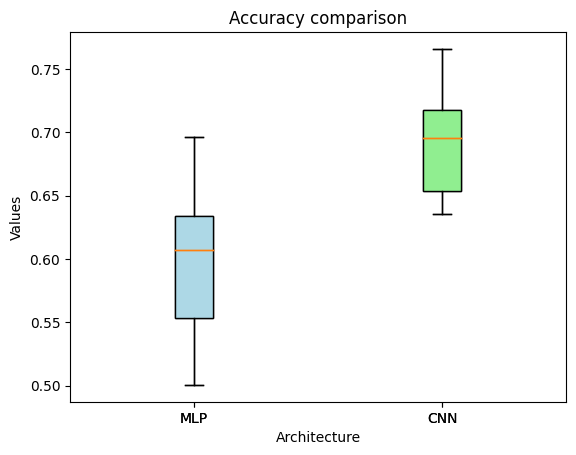

In [33]:
# Accuracy boxplot for model comparison

plt.boxplot(best_accs, labels=['MLP', 'CNN'], patch_artist=True)

colors = ['lightblue', 'lightgreen']
for patch, color in zip(plt.boxplot(best_accs, labels=['MLP', 'CNN'], patch_artist=True)['boxes'], colors):
    patch.set_facecolor(color)

plt.xlabel('Architecture')
plt.ylabel('Values')
plt.title('Accuracy comparison')
plt.show()

In [60]:
# Calculate the confusion matrix for each fold/model

confmat_mlp = []
confmat_cnn = []

for fold in range(1, 11):
  imported = tf.keras.models.load_model(f"models/UrbanSoundMLP{fold}")
  X_train, X_test, y_train, y_test = fold_division(fold=fold,
                                                   cnn_splits=False)
  y_pred = imported.predict(X_test).argmax(axis=1)
  y_true = y_test.argmax(axis=1)
  confmat = confusion_matrix(y_true, y_pred)
  confmat_mlp.append(confmat)

  imported = tf.keras.models.load_model(f"models/UrbanSoundCNN{fold}")
  X_train, X_test, y_train, y_test = fold_division(fold=fold,
                                                   cnn_splits=True)
  y_pred = imported.predict(X_test).argmax(axis=1)
  y_true = y_test.argmax(axis=1)
  confmat = confusion_matrix(y_true, y_pred)
  confmat_cnn.append(confmat)

27/27 [==============================] - 0s 3ms/step


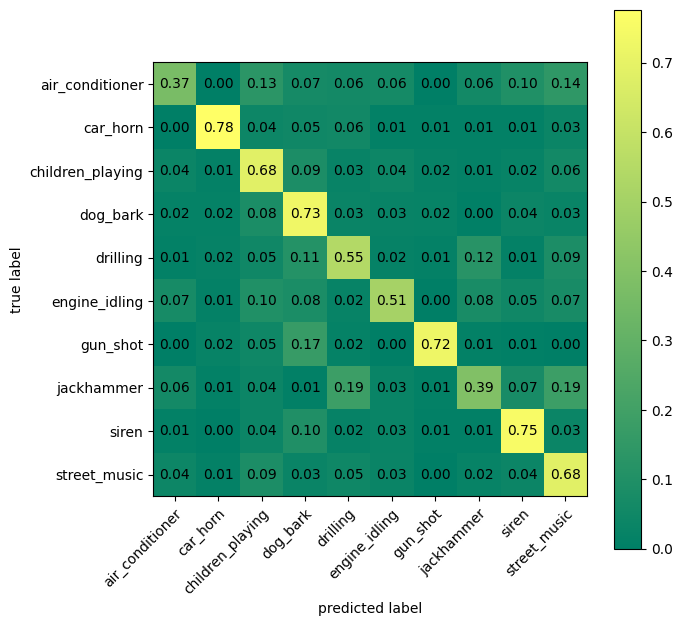

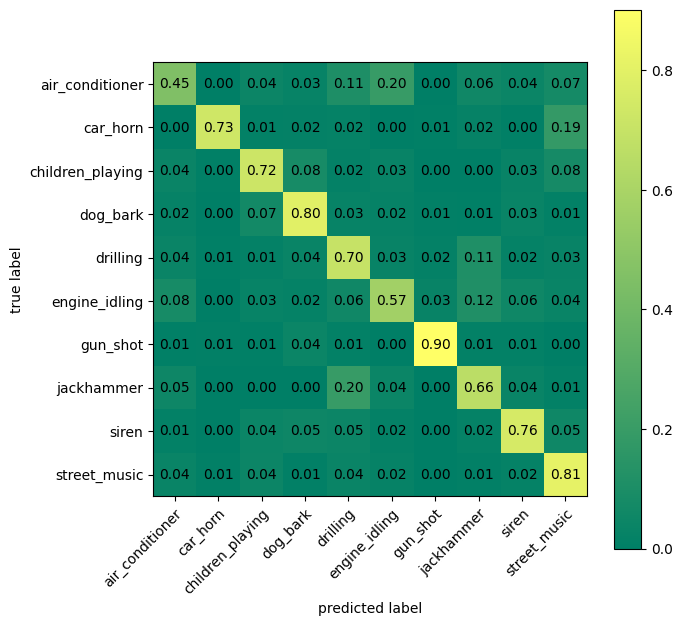

In [68]:
# Plotting the confusion matrices

confmat_mlp_np = np.sum(np.array(confmat_mlp), axis=0)
confmat_cnn_np = np.sum(np.array(confmat_cnn), axis=0)

fig, ax = plot_confusion_matrix(conf_mat=confmat_mlp_np,
                                colorbar=True,
                                show_normed=True,
                                show_absolute=False,
                                class_names=np.sort(df['class'].unique()),
                                cmap='summer',
                                fontcolor_threshold=1,
                                figsize=(7, 7))

fig, ax = plot_confusion_matrix(conf_mat=confmat_cnn_np,
                                colorbar=True,
                                show_normed=True,
                                show_absolute=False,
                                class_names=np.sort(df['class'].unique()),
                                cmap='summer',
                                fontcolor_threshold=1,
                                figsize=(7, 7))